In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

df = pd.read_csv("Dataset.csv")
df = df.drop_duplicates(subset="title").reset_index(drop=True)
print(df.shape)
df.head()

(8787, 10)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


TV-MA       3205
TV-14       2155
TV-PG        861
R            798
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: rating, dtype: int64


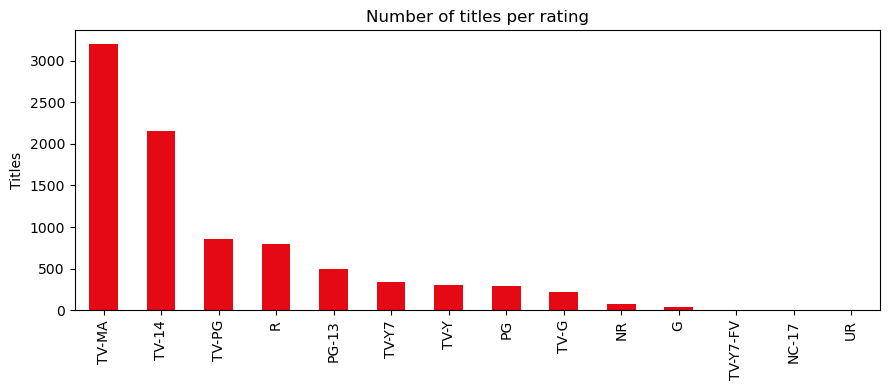

In [2]:
rating_counts = df["rating"].value_counts()
print(rating_counts)
rating_counts.plot(kind="bar", figsize=(9, 4), color="#e50914")
plt.title("Number of titles per rating"); plt.ylabel("Titles")
plt.tight_layout(); plt.show()

Removed unrated titles: 82
Kids       906
Family    1148
Teens     2645
Adults    4006
Name: audience, dtype: int64

Majority-class baseline accuracy: 0.46


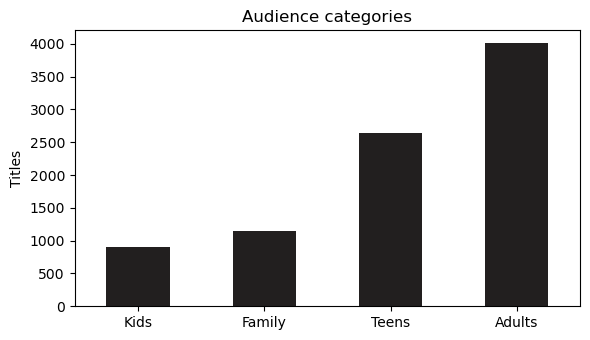

In [3]:
rating_map = {
    "TV-Y": "Kids", "TV-Y7": "Kids", "TV-Y7-FV": "Kids", "TV-G": "Kids", "G": "Kids",
    "TV-PG": "Family", "PG": "Family",
    "TV-14": "Teens", "PG-13": "Teens",
    "TV-MA": "Adults", "R": "Adults", "NC-17": "Adults",
}
df["audience"] = df["rating"].map(rating_map)
print("Removed unrated titles:", df["audience"].isna().sum())
df = df.dropna(subset=["audience"]).reset_index(drop=True)

order = ["Kids", "Family", "Teens", "Adults"]
aud_counts = df["audience"].value_counts().reindex(order)
print(aud_counts)
baseline = aud_counts.max() / aud_counts.sum()
print("\nMajority-class baseline accuracy:", round(baseline, 3))
aud_counts.plot(kind="bar", color="#221f1f", figsize=(6, 3.5))
plt.title("Audience categories"); plt.xticks(rotation=0); plt.ylabel("Titles")
plt.tight_layout(); plt.show()

In [ ]:
y = df["audience"]

genres = df["listed_in"].apply(lambda s: [t.strip().lower() for t in s.split(",")])
mlb = MultiLabelBinarizer()
G = pd.DataFrame(mlb.fit_transform(genres), columns=["genre_" + c for c in mlb.classes_])

added = pd.to_datetime(df["date_added"].str.strip(), format="%m/%d/%Y", errors="coerce")
duration_num = df["duration"].str.extract(r"(\d+)")[0].astype(float)
X_num = pd.DataFrame({
    "is_tv_show":   (df["type"] == "TV Show").astype(int),
    "release_year": df["release_year"],
    "year_added":   added.dt.year,
    "month_added":  added.dt.month,
    "minutes":      np.where(df["type"] == "Movie", duration_num, 0),    # movie length
    "seasons":      np.where(df["type"] == "TV Show", duration_num, 0),  # number of seasons
    "has_director": (df["director"] != "Not Given").astype(int),
    "n_countries":  df["country"].apply(lambda s: 0 if s == "Not Given" else len(s.split(","))),
    "n_genres":     genres.apply(len),
})
X_num = X_num.fillna(X_num.median())

top_countries = df["country"].value_counts().head(15).index
C = pd.get_dummies(df["country"].where(df["country"].isin(top_countries), "Other"), prefix="country")

X = pd.concat([X_num, C, G], axis=1).astype(float)
print("Feature matrix:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)

Feature matrix: (8705, 67)
Train: (6964, 67)  Test: (1741, 67)


In [5]:
models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
    "Decision Tree":       DecisionTreeClassifier(max_depth=8, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting":   HistGradientBoostingClassifier(random_state=42),
}

rows = []
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    rows.append({"Model": name,
                 "Accuracy": accuracy_score(y_test, pred),
                 "Macro F1": f1_score(y_test, pred, average="macro")})
results = pd.DataFrame(rows).set_index("Model")
results.loc["Always predict 'Adults' (baseline)"] = [baseline, np.nan]
results.round(4)

,Accuracy,Macro F1
Model,,
Logistic Regression,0.6278,0.5836
Decision Tree,0.5979,0.5523
Random Forest,0.6215,0.5815
Gradient Boosting,0.6364,0.6013
Always predict 'Adults' (baseline),0.4602,NaN


In [6]:
dt_grid = {
    "max_depth": [4, 6, 8, 12, None],
    "min_samples_leaf": [1, 5, 10],
    "criterion": ["gini", "entropy"],
}
dt_search = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_grid,
                         cv=3, scoring="f1_macro", n_jobs=-1)
dt_search.fit(X_train, y_train)
print("Decision Tree best params:", dt_search.best_params_)
print("Decision Tree best CV macro F1:", round(dt_search.best_score_, 4))

Decision Tree best params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 10}
Decision Tree best CV macro F1: 0.5816


In [7]:
rf_grid = {
    "max_depth": [None, 20],
    "min_samples_leaf": [1, 3],
    "class_weight": [None, "balanced"],
}
rf_search = GridSearchCV(RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
                         rf_grid, cv=3, scoring="f1_macro", n_jobs=1)
rf_search.fit(X_train, y_train)      # this cell takes about a minute
print("Random Forest best params:", rf_search.best_params_)
print("Random Forest best CV macro F1:", round(rf_search.best_score_, 4))

Random Forest best params: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 3}
Random Forest best CV macro F1: 0.6328


In [8]:
tuned = {"Decision Tree (tuned)": dt_search.best_estimator_,
         "Random Forest (tuned)": rf_search.best_estimator_}
rows = []
for name, m in tuned.items():
    pred = m.predict(X_test)
    rows.append({"Model": name,
                 "Accuracy": accuracy_score(y_test, pred),
                 "Macro F1": f1_score(y_test, pred, average="macro")})
tuned_results = pd.DataFrame(rows).set_index("Model")

all_results = pd.concat([results.drop(index="Always predict 'Adults' (baseline)"), tuned_results])
all_results.round(4)

,Accuracy,Macro F1
Model,,
Logistic Regression,0.6278,0.5836
Decision Tree,0.5979,0.5523
Random Forest,0.6215,0.5815
Gradient Boosting,0.6364,0.6013
Decision Tree (tuned),0.5951,0.5754
Random Forest (tuned),0.6301,0.6109


In [9]:
best_name = all_results["Macro F1"].idxmax()
all_models = {**models, **tuned}
best = all_models[best_name]
pred = best.predict(X_test)
print("Best model by macro F1:", best_name, "\n")
print(classification_report(y_test, pred, labels=order))

Best model by macro F1: Random Forest (tuned) 

              precision    recall  f1-score   support

        Kids       0.79      0.72      0.75       181
      Family       0.44      0.46      0.45       230
       Teens       0.54      0.49      0.52       529
      Adults       0.70      0.75      0.72       801

    accuracy                           0.63      1741
   macro avg       0.62      0.61      0.61      1741
weighted avg       0.63      0.63      0.63      1741



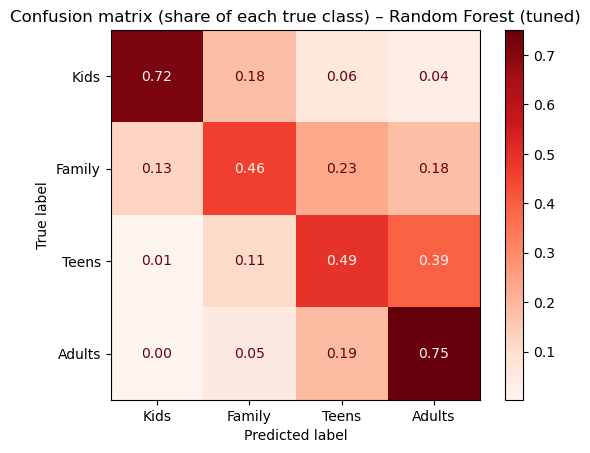

In [10]:
ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=order,
                                        normalize="true", cmap="Reds", values_format=".2f")
plt.title(f"Confusion matrix (share of each true class) – {best_name}")
plt.show()

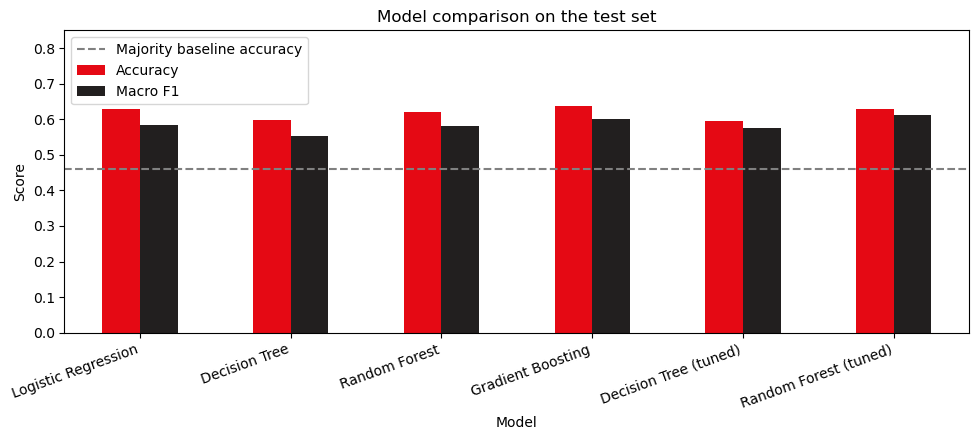

In [11]:
ax = all_results[["Accuracy", "Macro F1"]].plot(kind="bar", figsize=(10, 4.5), color=["#e50914", "#221f1f"])
ax.axhline(baseline, color="gray", linestyle="--", label="Majority baseline accuracy")
ax.set_ylim(0, 0.85); ax.set_ylabel("Score"); ax.legend(loc="upper left")
plt.title("Model comparison on the test set"); plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()

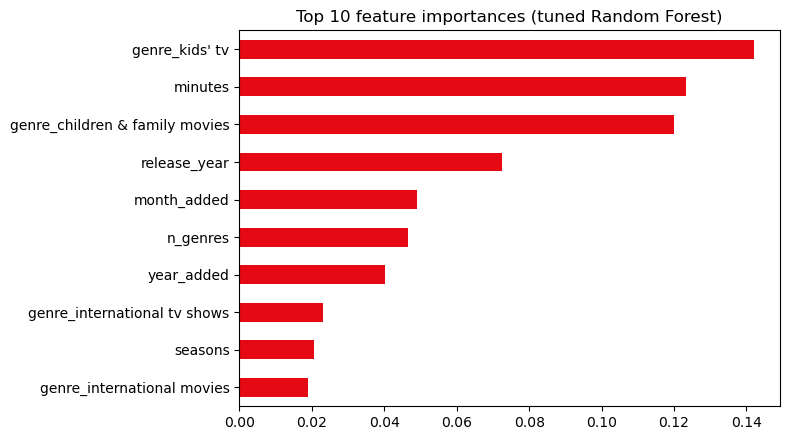

In [12]:
rf_best = rf_search.best_estimator_
imp = pd.Series(rf_best.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
imp[::-1].plot(kind="barh", figsize=(8, 4.5), color="#e50914")
plt.title("Top 10 feature importances (tuned Random Forest)")
plt.tight_layout(); plt.show()